This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment ACTIVE model to our real, experimental data.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

We initialize the NN based on https://arxiv.org/pdf/2311.15890, and with it we get stable u values.

Here we try to use an adaptive dt value, which is different for the spiking and non-spiking regions.

After the first training (dtw loss with some spike-height punishment) we choose the best 40 models to fine-tune (sse loss).

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"


%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx
import flax.nnx as nnx

from voltage_fitting.loss_util import (
    get_scaled_loss,
)



Let's see our data!

In [4]:
t_max = 80.0
cut = 1500
cut_time = 37.5

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


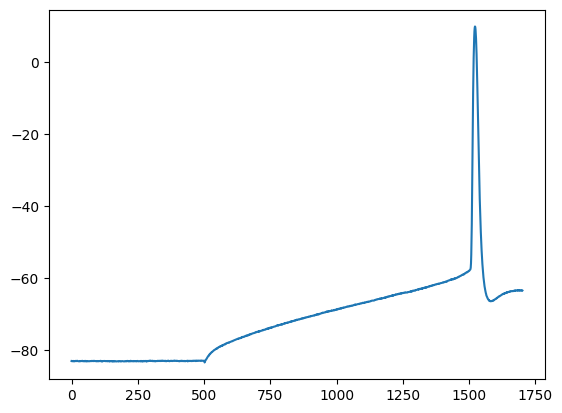

In [5]:
plt.plot(v_data[0])

In [6]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


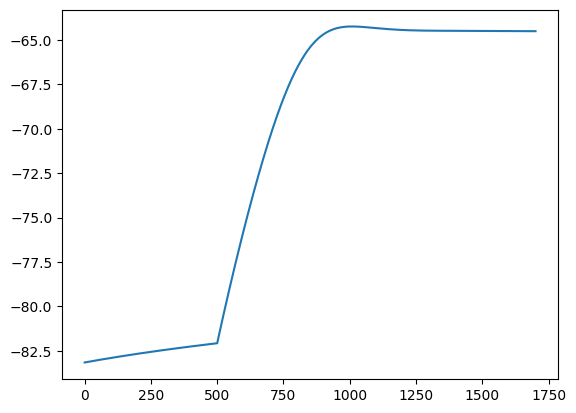

In [7]:
plt.plot(v_single[0])

**Initialization**

In [8]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices

)

In [9]:
key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   # RK4
    h=dt,
    u_dim=u_dimension,
    use_complex=True
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, "scaled: ", dt*e)

Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) scaled:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) scaled:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) scaled:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) scaled:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) scaled:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) scaled:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) scaled:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) scaled:  (-0.9220778457683627+0.47510614586898203j)


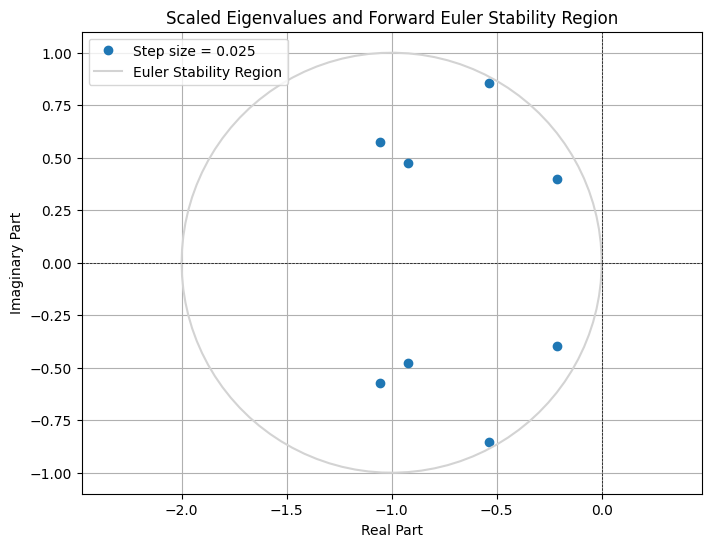

In [10]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Now we make the Lambda, Pi and W matrices based on the paper

In [11]:
num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

In [12]:
# Checking the eigenvalues of the generated initialization
jnp.linalg.eigvals(W_matrices[2]@W_matrices[1]@W_matrices[0][:, :u_dimension])

Array([-42.14161353+22.98417698j, -42.14161353-22.98417698j,
       -21.54550625+34.14736393j, -21.54550625-34.14736393j,
       -36.88311383+19.00424583j, -36.88311383-19.00424583j,
        -8.51603533+15.86861961j,  -8.51603533-15.86861961j],      dtype=complex128)

In [13]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [14]:
import jax
import jax.numpy as jnp
import equinox as eqx
import jax.random as jr
from typing import List

class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)

        # Manually override weights and biases
        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)

In [16]:
# We have to take care of the different amount of predicted points in the simulation (based on spiking regions).
# That's why we always have to decide if we store a point and that makes the training much slower.

dt = 0.025
max_add_current = 1.0

dt_normal = 0.025
dt_spike = 0.0125
v_threshold = 0.5 

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, u_time_constant, thr = None):
    @jax.jit
    def update_buffers(bufs, cond, idx, new_vals):
        return jax.lax.cond(
            cond,
            lambda _: tuple(b.at[idx].set(v) for b, v in zip(bufs, new_vals)),
            lambda _: bufs,
            operand=None
        )
    
    def cond_fn(carry):
        t_sim, t_idx, _, _, _, diff, _ = carry
        keep_running = t_idx < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t_sim, t_idx, state, u, (new_us, new_recs, new_adds), diff, prev_voltage = carry


        #voltage = state["v"][rec_inds].squeeze()
        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)
        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        dv = jnp.abs(voltage - prev_voltage)
        dt_use = jnp.where(dv > v_threshold, dt_spike, dt_normal)
        
        u_new = u + dt_use*neural_net(inputs) / u_time_constant #0.02 #0.0008
        add_current = readout_net(u_new).squeeze()


        total_current = current[t_idx] + add_current * added_curr_std #/300 #10

        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]
        
        should_store = t_sim >= t_idx * dt_normal

        # new_us = jax.lax.cond(should_store, lambda buf: buf.at[t_idx].set(u_new), lambda buf: buf, new_us)
        # new_recs = jax.lax.cond(should_store, lambda buf: buf.at[t_idx].set(rec_voltage), lambda buf: buf, new_recs)
        # new_adds = jax.lax.cond(should_store, lambda buf: buf.at[t_idx].set(add_current), lambda buf: buf, new_adds)
        # nn_reses = jax.lax.cond(should_store, lambda buf: buf.at[t_idx].set(nn_res), lambda buf: buf, nn_reses)
        # new_diff = jax.lax.cond(should_store, lambda d: d + (rec_voltage - x_o[t_idx + 1])**2, lambda d: d, diff)
        # new_dts = jax.lax.cond(should_store, lambda buf: buf.at[t_idx].set(dt_use), lambda buf: buf, new_dts)
        # tnns = tnns.at[t].set(t_nn)

        (new_us, new_recs, new_adds) = update_buffers((new_us, new_recs, new_adds), should_store, t_idx, (u_new, rec_voltage, add_current))
        
        new_diff = jax.lax.cond(should_store, lambda d: d + (rec_voltage - x_o[t_idx + 1])**2, lambda d: d, diff)
        new_t_idx = jax.lax.cond(should_store, lambda x: x + 1, lambda x: x, t_idx)

        return (t_sim + dt_use, new_t_idx, state, u_new.squeeze(), (new_us, new_recs, new_adds), new_diff, voltage)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    carry = (0.0, 0, initial_state, u_init.squeeze(), (us, recs, adds), 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec) * 10,
        kind="bounded"
    )

   
    _, _, _, _, (us, recs, adds), _, _ = final_carry

    return recs, adds, us

In [17]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, us = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return scaled_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg + add_loss * add_reg

In [18]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

rngs = nnx.Rngs(1)
key = jax.random.PRNGKey(0)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)


log_uniform_samples = jax.random.uniform(key, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
u_time_constant = jnp.exp(log_uniform_samples)
added_curr_std = 1.0/10.0 #1/50


thr = None


initial_lr = 15e-4
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400 # after x epochs, stop decaying
decay_start = 1 
decay_end = 350 


opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = CorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)


def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr


adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(
            optax.scale_by_lbfgs(memory_size = 6), #8
            optax.scale(-1e-3), #0.3
        )
adamw_optimizer = optax.adamw(
    learning_rate=custom_schedule, 
    weight_decay=1e-4              
)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)

def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr, dtw_reg= 1.0, spike_reg = 2.0, sse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr, dtw_reg= 0.0, spike_reg = 1000.0, sse_reg = 1.0, add_reg = 0.0)
        return loss



grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
# cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
# cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [19]:
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.neural_net, grads, clip_net(grads.neural_net))
    grads = eqx.tree_at(lambda g: g.readout_net, grads, clip_net(grads.readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_main, lr_channel):
    grads_main_scaled = jax.tree_util.tree_map(lambda g: g * lr_main, grads)
    grads_channel_scaled = grads.channel_params_normal * lr_channel

    return eqx.tree_at(
        lambda g: g.channel_params_normal,
        grads_main_scaled,
        grads_channel_scaled
    )

In [20]:
num_epochs = 400 
mean_losses = []
best_losses = jnp.full((n_particles,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []

for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(models)
    grads_list.append(grads)
    
  
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_main=1e-2, lr_channel=1.0)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mean_losses.append(jnp.mean(loss))

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")

        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 268.825380, Median Loss 259.124031, Min Loss: 146.275058
9.999999999995785 6.813176577757755 9.999999999971045 9.766267603301173 9.999999999966866 8.258079517720036 9.999999999997495 8.667203847555456 9.9999999999863 9.99999999999904 9.999999999994312
Epoch 10, Mean Loss: 245.857485, Median Loss 236.109807, Min Loss: 145.689866
9.999999999996199 6.949318604342094 9.99999999997787 9.47699407694593 9.999999999974627 9.264279448364544 9.999999999998002 9.704172411105752 9.999999999976612 9.999999999998694 9.999999999989369
Epoch 20, Mean Loss: 239.941641, Median Loss 231.950600, Min Loss: 136.177542
9.999999999993623 7.252031117137864 9.999999999979783 9.504689749339535 9.999999999990267 8.997669134425045 9.999999999998634 9.754327793694376 9.999999999980377 9.999999999998199 9.999999999991628
Epoch 30, Mean Loss: 235.725966, Median Loss 227.765297, Min Loss: 76.487266
9.999999999999602 8.588036650085082 9.999999999994067 9.460475792920779 9.99999999999324 8.8675387890

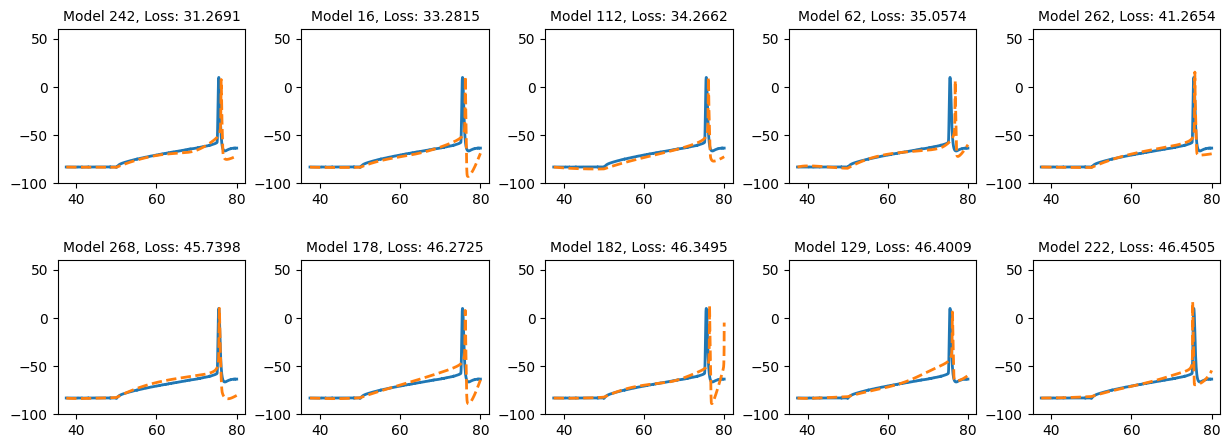

In [22]:
#t=80.0, spike_reg = 2.0
inds = np.argsort(best_losses)
best_ten_preds = []
best_ten_losses = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        best_ten_preds.append(final_preds)
        best_ten_losses.append(best_losses[inds[i*5+j]])
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

best_ten_preds = np.stack(best_ten_preds)
np.save("../results/best_preds_adaptive.npy", best_ten_preds)
np.save("../results/losses_adaptive.npy", best_ten_losses)

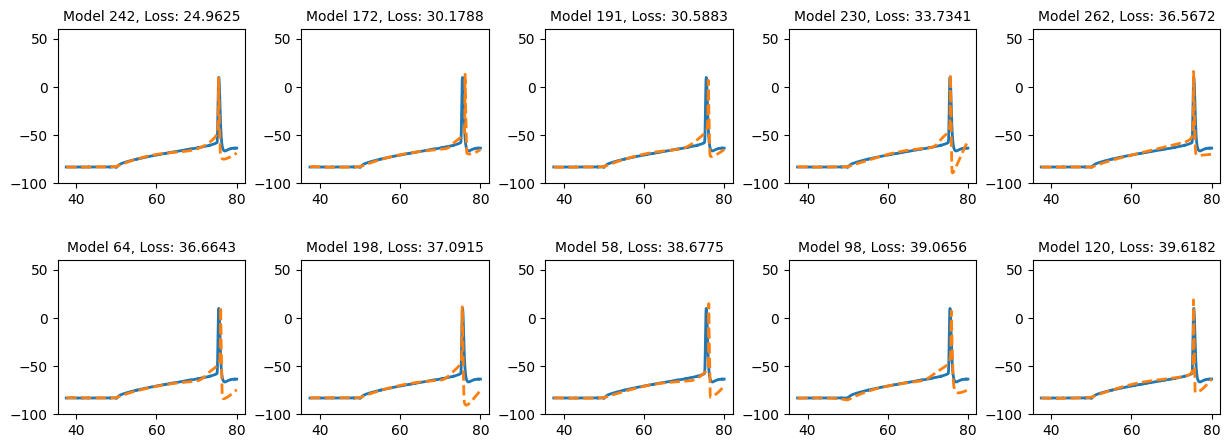

In [ ]:
#t=80.0, spike_reg = 0.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Checking one prediction - Why are most of the us exploding?:**

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


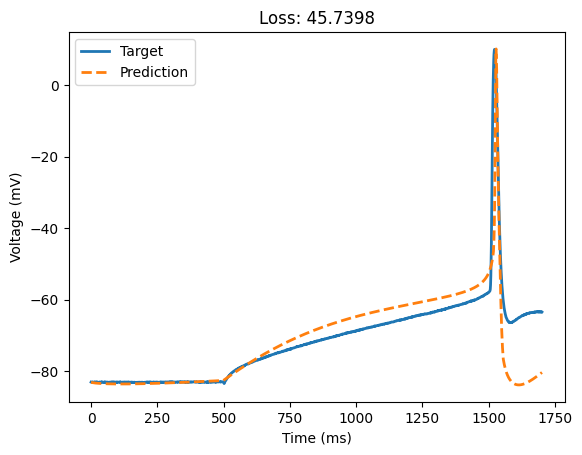

In [34]:
idx = 5
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us = simulate_full_trace(
    model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])


Text(0.5, 1.0, 'Additional current')

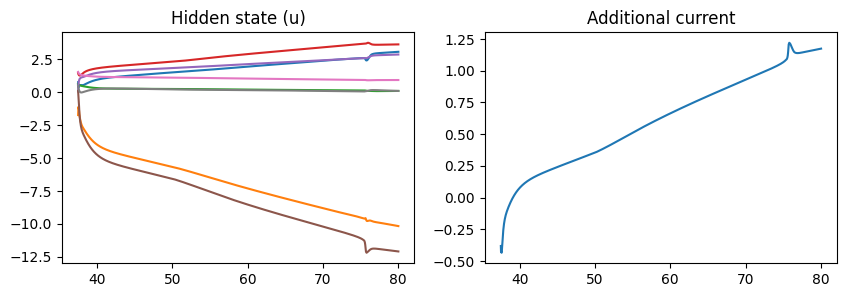

In [35]:
fig, axs = plt.subplots(1,2, figsize = (10,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden state (u)")
axs[1].plot(time_vec, final_additional_currents)
axs[1].set_title("Additional current")
# axs[2].plot(time_vec, final_nn_reses)
# axs[2].set_title("Neural network output (neural_net)")

**Fine-tuning the best 40 models**

In [37]:
top_k = 40
top_k_inds = inds[:top_k]
top_k_models = jax.tree_util.tree_map(lambda x: x[top_k_inds], best_models)
#top_k_losses = best_losses[top_k_inds]
top_k_losses = jnp.full((top_k,), jnp.inf)

fine_tune_lr = 1e-4
decay_start = 100
decay_end = 200

fine_schedule = optax.exponential_decay(
    init_value=fine_tune_lr,
    transition_steps=1,
    decay_rate=1,
    staircase=True,
)
def fine_custom_schedule(step):
    # Epochs before decay_start → constant
    lr = fine_tune_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        fine_tune_lr,
        fine_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = fine_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

fine_optimizer = optax.adam(fine_custom_schedule)
# fine_optimizer = optax.sgd(learning_rate=1e-8, momentum=0.9)
# fine_optimizer = optax.chain(
#             optax.scale_by_lbfgs(memory_size = 8), #8
#             optax.scale(-1e-3), #0.3
#         )

fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

num_fine_epochs = 300
fine_mean_losses = []
fine_best_models = top_k_models
fine_best_losses = top_k_losses

for epoch in range(num_fine_epochs):
    # if epoch == 0: #370
    #     fine_optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 6), #8
    #         optax.scale(-0.1e-1), #0.3
    #     )
    #     fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

    loss, grads = fine_grad_fn(top_k_models)

    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    grads = scale_grads(grads, lr_main=1e-4, lr_channel=1.0)

    improved = loss < fine_best_losses
    fine_best_losses = jnp.where(improved, loss, fine_best_losses)
    fine_best_models = jax.tree_util.tree_map(replace_if_improved, top_k_models, fine_best_models)

    updates, fine_optimizer_states = jax.vmap(lambda g, s, m: fine_optimizer.update(g, s, m, step=epoch))(grads, fine_optimizer_states, top_k_models)
    top_k_models = jax.vmap(eqx.apply_updates)(top_k_models, updates)

    fine_mean_losses.append(jnp.mean(loss))

    if epoch % 10 == 0:
        print(f"Fine-tune epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")
        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear1.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear2.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear3.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear3.bias, axis=1)))


/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Fine-tune epoch 0, Mean Loss: 101941.573910, Median Loss 104899.957762, Min Loss: 48651.346659
10.0 31421.92071534262 2621.1651328094717 58808.743497068564 3731.6063599519557 9845.253878377898 64986.59643819841
Fine-tune epoch 10, Mean Loss: 159500.537487, Median Loss 162202.726711, Min Loss: 36475.889713
9.999999999999991 8010.881497061349 727.8894411177881 11672.03188178521 1307.2498338976054 5275.890916083326 39604.245348055316
Fine-tune epoch 20, Mean Loss: 162939.602278, Median Loss 160281.997539, Min Loss: 35818.206588
9.999999999999996 9404.2318569495 618.1806533102819 15723.99520462288 1864.0078083956862 5936.3683916293985 32407.512813879548
Fine-tune epoch 30, Mean Loss: 164801.277574, Median Loss 163571.601887, Min Loss: 36680.631495
9.999999999999993 7615.098112746083 213.38983586581676 8474.320080274554 332.90762788079473 2806.8938548338892 5682.748931570402
Fine-tune epoch 40, Mean Loss: 166793.446713, Median Loss 165059.021659, Min Loss: 37649.485379
9.999999999999984 486

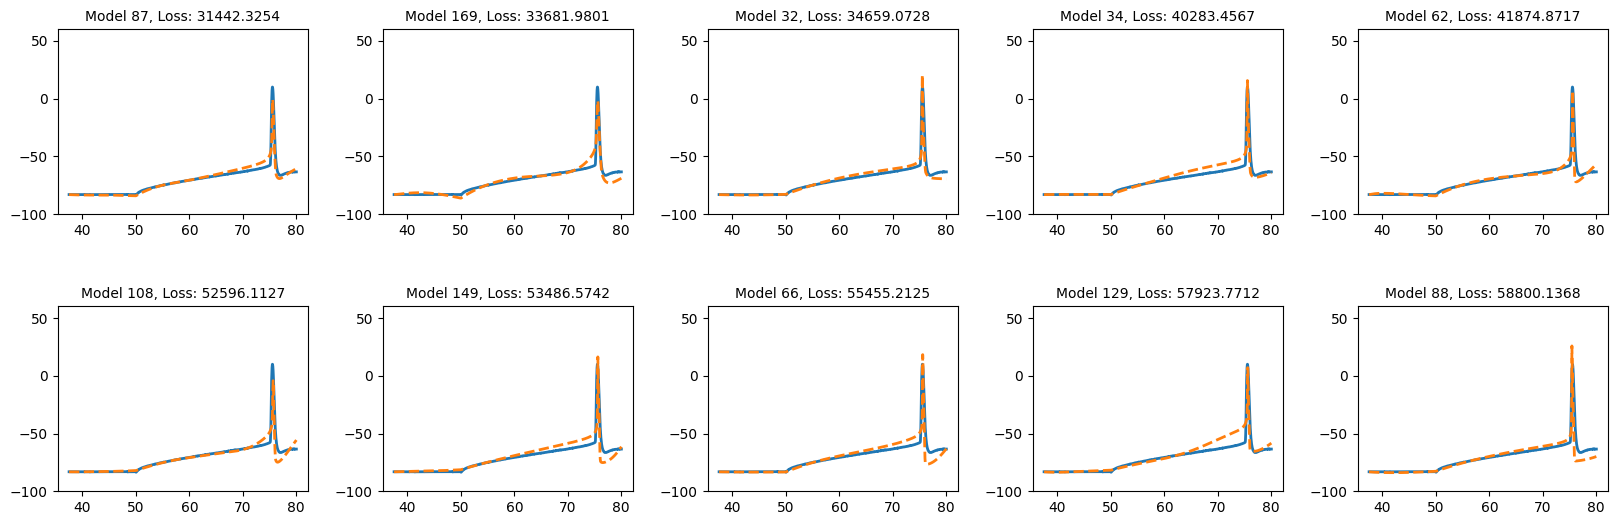

In [38]:
fine_inds = np.argsort(fine_best_losses)
fig, axs = plt.subplots(2,5, figsize = (20,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[fine_inds[i*5+j]], fine_best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[fine_inds[i*5+j]]}, Loss: {fine_best_losses[fine_inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


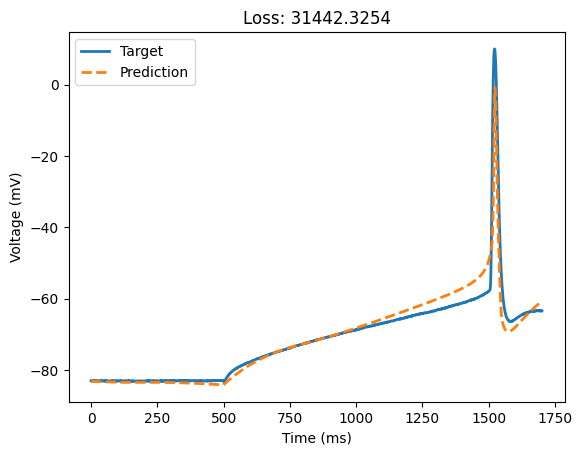

In [39]:
idx = 0

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[fine_inds[idx]], fine_best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us = simulate_full_trace(
    model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
)

loss = fine_simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])